
# 🌍 GROW Dataset Explorer: Building Towards a Groundwater Foundation Model for Africa

**Objective:** Explore the GROW dataset (Bäthge et al., 2026) to understand its structure, assess African data availability, and lay the groundwork for building a groundwater dynamics foundation model.

**Paper:** A Global-Scale Time Series Dataset for Groundwater Studies within the Earth System (Nature Scientific Data, 2026)

**Dataset:** https://doi.org/10.5281/zenodo.15149480

---


## Phase 1: Setup and Data Download

In [1]:
# Install required packages
!pip install pyarrow fastparquet geopandas matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully!')

Libraries loaded successfully!


### Download GROW Dataset from Zenodo

⚠️ **Important:** The GROW dataset is large. We'll download the **attributes table** first (smaller) to explore metadata, then selectively load time series.

**Manual step:** Go to https://doi.org/10.5281/zenodo.15149480 and download:
1. `GROW_attributes.parquet` (small, ~50MB)
2. `GROW_timeseries.parquet` (large, several GB)

Upload `GROW_attributes.parquet` to your Google Drive or Colab files first.

Alternatively, if the Zenodo API allows direct download:

In [3]:
# Download directly to Colab (check exact URL from Zenodo page)
!wget -O /content/GROW_attributes.parquet 'https://zenodo.org/records/15149480'

--2026-04-12 15:11:44--  https://zenodo.org/records/15149480
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.43.153, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139251 (136K) [text/html]
Saving to: ‘/content/GROW_attributes.parquet’

/content/GROW_attri 100%[===================>] 135.99K   629KB/s    in 0.2s    

2026-04-12 15:11:46 (629 KB/s) - ‘/content/GROW_attributes.parquet’ saved [139251/139251]



In [4]:
!wget -O /content/data.zip 'https://zenodo.org/records/15149480/files/data.zip?download=1'

--2026-04-12 15:11:46--  https://zenodo.org/records/15149480/files/data.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.43.153, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3587444108 (3.3G) [application/octet-stream]
Saving to: ‘/content/data.zip’

/content/data.zip   100%[===================>]   3.34G  27.2MB/s    in 2m 7s   

2026-04-12 15:13:53 (27.0 MB/s) - ‘/content/data.zip’ saved [3587444108/3587444108]



In [5]:
!unzip /content/data.zip -d /content/GROW/

Archive:  /content/data.zip
   creating: /content/GROW/data/
  inflating: /content/GROW/data/grow_attributes.csv  
  inflating: /content/GROW/data/grow_attributes.json  
  inflating: /content/GROW/data/grow_attributes.parquet  
  inflating: /content/GROW/data/grow_timeseries.csv  
  inflating: /content/GROW/data/grow_timeseries.parquet  


In [6]:
!ls /content/GROW/

data


In [7]:
import pandas as pd

df_attr = pd.read_parquet('/content/GROW/data/grow_attributes.parquet')
print(f'Total wells: {len(df_attr):,}')
print(f'Columns: {len(df_attr.columns)}')
print(f'\nFirst few column names:')
for i, col in enumerate(df_attr.columns):
    print(f'  {i+1}. {col}')

Total wells: 204,292
Columns: 54

First few column names:
  1. GROW_ID
  2. original_ID_groundwater
  3. name
  4. feature_type
  5. purpose
  6. status
  7. description
  8. latitude
  9. longitude
  10. provider_ground_elevation_m_asl
  11. top_of_well_elevation_m_asl
  12. total_drilling_depth_m
  13. country
  14. address
  15. aquifer_name
  16. confinement
  17. organisation
  18. manager
  19. license
  20. interval
  21. aggregated_from_n_values_median
  22. starting_date
  23. ending_date
  24. length_years
  25. autocorrelation
  26. gap_fraction
  27. negative_signs_wtd
  28. outliers_change_points
  29. plateaus
  30. trend_direction
  31. trend_slope_m_year-1
  32. reference_point
  33. groundwater_mean_m
  34. groundwater_median_m
  35. koeppen_geiger_class
  36. hydrobelt_class
  37. ground_elevation_merit_m_asl
  38. topographic_slope_degree
  39. rock_type_0-100_m_class
  40. aquifer_type_class
  41. permeability_0-100_m_m-2
  42. total_porosity_0-100_m_fraction
  43. 

In [8]:
print(f'\nCountries: {df_attr["country"].nunique()}')
print(f'\nTop 10 countries:')
print(df_attr['country'].value_counts().head(10))


Countries: 55

Top 10 countries:
country
USA    101003
IND     33814
AUS     21384
FRA     13314
MEX      7433
ESP      3602
DNK      3395
ZAF      3301
NZL      2478
NLD      2383
Name: count, dtype: int64


In [9]:
# Check all unique countries to find African ones
print('\nAll countries in GROW:')
for c in sorted(df_attr['country'].unique()):
    print(f'  {c}')


All countries in GROW:
  AFG
  AUS
  AUT
  BEL
  BGR
  BRA
  CAN
  CHE
  CHL
  CHN
  CRI
  CUB
  CZE
  DEU
  DNK
  ESP
  EST
  FIN
  FRA
  GBR
  GMB
  HRV
  IND
  IRL
  ISR
  ITA
  JAM
  KOR
  LSO
  LTU
  LUX
  LVA
  MDG
  MEX
  MOZ
  MYS
  NAM
  NGA
  NLD
  NOR
  NPL
  NZL
  PRT
  PSE
  RWA
  SLE
  SLV
  SOM
  SVN
  SWE
  THA
  TWN
  UGA
  USA
  ZAF


In [10]:
!rm /content/data.zip

In [11]:
african_codes = ['GMB', 'LSO', 'MDG', 'MOZ', 'NAM', 'NGA', 'RWA', 'SLE', 'SOM', 'UGA', 'ZAF']

df_africa = df_attr[df_attr['country'].isin(african_codes)]

print(f'African wells: {len(df_africa):,}')
print(f'Percentage of total: {len(df_africa)/len(df_attr)*100:.2f}%')
print(f'\nAfrican countries found:')
print(df_africa['country'].value_counts())
print(f'\nFor context:')
print(f'  GMB = Gambia')
print(f'  LSO = Lesotho')
print(f'  MDG = Madagascar')
print(f'  MOZ = Mozambique')
print(f'  NAM = Namibia')
print(f'  NGA = Nigeria')
print(f'  RWA = Rwanda')
print(f'  SLE = Sierra Leone')
print(f'  SOM = Somalia')
print(f'  UGA = Uganda')
print(f'  ZAF = South Africa')

African wells: 3,538
Percentage of total: 1.73%

African countries found:
country
ZAF    3301
NAM      84
RWA      43
GMB      36
LSO      16
MOZ      14
NGA      14
UGA      10
MDG      10
SLE       6
SOM       4
Name: count, dtype: int64

For context:
  GMB = Gambia
  LSO = Lesotho
  MDG = Madagascar
  MOZ = Mozambique
  NAM = Namibia
  NGA = Nigeria
  RWA = Rwanda
  SLE = Sierra Leone
  SOM = Somalia
  UGA = Uganda
  ZAF = South Africa


In [12]:
print('GLOBAL vs AFRICA COMPARISON')
print('='*50)

# Climate zones
print('\nClimate zones (Global):')
print(df_attr['koeppen_geiger_class'].value_counts().head(10))
print('\nClimate zones (Africa):')
print(df_africa['koeppen_geiger_class'].value_counts())

# Aquifer types
print('\nAquifer types (Global):')
print(df_attr['aquifer_type_class'].value_counts())
print('\nAquifer types (Africa):')
print(df_africa['aquifer_type_class'].value_counts())

# Time series length
print(f'\nMedian time series length (Global): {df_attr["length_years"].median():.1f} years')
print(f'Median time series length (Africa): {df_africa["length_years"].median():.1f} years')

# Groundwater depth
print(f'\nMedian groundwater depth (Global): {df_attr["groundwater_median_m"].median():.1f} m')
print(f'Median groundwater depth (Africa): {df_africa["groundwater_median_m"].median():.1f} m')

# Trends
print('\nTrend direction (Global):')
print(df_attr['trend_direction'].value_counts())
print('\nTrend direction (Africa):')
print(df_africa['trend_direction'].value_counts())

GLOBAL vs AFRICA COMPARISON

Climate zones (Global):
koeppen_geiger_class
BSk     33853
Cfb     26707
LCsb    26610
Cfa     26292
Csa     25474
Aw      19046
BSh     11779
Cwa     11744
BWh      5431
Dfa      5076
Name: count, dtype: int64

Climate zones (Africa):
koeppen_geiger_class
BSk     953
BSh     826
Cwb     505
Cfb     332
BWh     231
LCsb    180
Csa     166
Cwa     100
Aw       74
BWk      69
Cfa      47
As       32
Am       17
Af        6
Name: count, dtype: int64

Aquifer types (Global):
aquifer_type_class
porous              81486
fractured           42543
porous/fractured    39982
karst               27751
water_body           5346
Name: count, dtype: int64

Aquifer types (Africa):
aquifer_type_class
porous/fractured    1344
fractured            730
karst                693
porous               626
water_body             6
Name: count, dtype: int64

Median time series length (Global): 10.0 years
Median time series length (Africa): 6.0 years

Median groundwater depth (Glob

In [13]:
# Save the Africa analysis
summary = {
    'total_global_wells': len(df_attr),
    'total_african_wells': len(df_africa),
    'african_percentage': len(df_africa)/len(df_attr)*100,
    'african_countries': len(df_africa['country'].unique()),
    'nigeria_wells': len(df_africa[df_africa['country']=='NGA']),
    'usa_wells': len(df_attr[df_attr['country']=='USA']),
    'median_depth_global': df_attr['groundwater_median_m'].median(),
    'median_depth_africa': df_africa['groundwater_median_m'].median(),
    'median_length_global': df_attr['length_years'].median(),
    'median_length_africa': df_africa['length_years'].median(),
}

import json
with open('/content/grow_africa_assessment.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Summary saved!')
print(json.dumps(summary, indent=2))

Summary saved!
{
  "total_global_wells": 204292,
  "total_african_wells": 3538,
  "african_percentage": 1.7318348246627375,
  "african_countries": 11,
  "nigeria_wells": 14,
  "usa_wells": 101003,
  "median_depth_global": 8.400288,
  "median_depth_africa": 13.421,
  "median_length_global": 10.0,
  "median_length_africa": 6.0
}


Phase 2: baseline models.

In [14]:
import pyarrow.parquet as pq

# Read only the schema (no data loaded into memory)
schema = pq.read_schema('/content/GROW/data/grow_timeseries.parquet')
print('Time series columns:')
for i, name in enumerate(schema.names):
    print(f'  {i+1}. {name}')

Time series columns:
  1. GROW_ID
  2. interval
  3. date
  4. year
  5. month
  6. aggregated_from_n_values
  7. outliers_change_points
  8. plateaus
  9. groundwater_depth_from_ground_elevation_m
  10. groundwater_depth_from_well_top_elevation_m
  11. groundwater_water_level_elevation_m_asl
  12. groundwater_filled_depth_from_ground_elevation_m
  13. groundwater_filled_depth_from_well_top_elevation_m
  14. groundwater_filled_water_level_elevation_m_asl
  15. precipitation_mswep_mm_year-1
  16. precipitation_gpcc_mm_year-1
  17. potential_evapotranspiration_era5_mm_year-1
  18. potential_evapotranspiration_gleam_mm_year-1
  19. actual_evapotranspiration_mm_year-1
  20. interception_mm_year-1
  21. air_temperature_°C
  22. snow_depth_m
  23. days_with_snow_cover_days_year-1
  24. ndvi_ratio
  25. lai_low_vegetation_ratio
  26. lai_high_vegetation_ratio
  27. withdrawal_industrial_m3_year-1
  28. withdrawal_domestic_m3_year-1
  29. urban_area_fraction
  30. pastures_fraction
  31. cropl

In [15]:
import pandas as pd

# Get 10,000 yearly wells
yearly_wells = df_attr[df_attr['interval'] == 'YS']['GROW_ID'].tolist()[:10000]

df_ts = pd.read_parquet(
    '/content/GROW/data/grow_timeseries.parquet',
    filters=[('GROW_ID', 'in', yearly_wells)],
    columns=[
        'GROW_ID', 'year',
        'groundwater_depth_from_ground_elevation_m',
        'precipitation_mswep_mm_year-1',
        'precipitation_gpcc_mm_year-1',
        'potential_evapotranspiration_era5_mm_year-1',
        'actual_evapotranspiration_mm_year-1',
        'air_temperature_°C',
        'ndvi_ratio',
        'withdrawal_domestic_m3_year-1',
        'withdrawal_industrial_m3_year-1',
        'urban_area_fraction',
        'cropland_irrigated_fraction',
        'forests_natural_vegetation_fraction'
    ]
)

print(f'Rows: {len(df_ts):,}')
print(f'Unique wells: {df_ts["GROW_ID"].nunique():,}')
print(f'Memory: {df_ts.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'\nYear range: {df_ts["year"].min()} - {df_ts["year"].max()}')
print(f'\nMissing values:')
print(df_ts.isnull().sum())

Rows: 100,352
Unique wells: 10,000
Memory: 17 MB

Year range: 1964 - 2025

Missing values:
GROW_ID                                            0
year                                               0
groundwater_depth_from_ground_elevation_m       2516
precipitation_mswep_mm_year-1                     78
precipitation_gpcc_mm_year-1                   23024
potential_evapotranspiration_era5_mm_year-1     3695
actual_evapotranspiration_mm_year-1            11211
air_temperature_°C                              3695
ndvi_ratio                                       562
withdrawal_domestic_m3_year-1                  17596
withdrawal_industrial_m3_year-1                17596
urban_area_fraction                            17702
cropland_irrigated_fraction                    17702
forests_natural_vegetation_fraction            17702
dtype: int64


In [16]:
# Merge static Earth system attributes with time series
static_features = [
    'GROW_ID', 'ground_elevation_merit_m_asl', 'topographic_slope_degree',
    'permeability_0-100_m_m-2', 'total_porosity_0-100_m_fraction',
    'soil_saturated_conductivity_0-30_cm_cm_d-1',
    'distance_perennial_streams_m', 'drainage_density_m-1',
    'days_with_snow_cover_average_days_year-1'
]

df_merged = df_ts.merge(df_attr[static_features], on='GROW_ID', how='left')

# Define target and features
target = 'groundwater_depth_from_ground_elevation_m'

features = [
    'precipitation_mswep_mm_year-1',
    'potential_evapotranspiration_era5_mm_year-1',
    'air_temperature_°C',
    'ndvi_ratio',
    'ground_elevation_merit_m_asl',
    'topographic_slope_degree',
    'permeability_0-100_m_m-2',
    'total_porosity_0-100_m_fraction',
    'soil_saturated_conductivity_0-30_cm_cm_d-1',
    'distance_perennial_streams_m',
    'drainage_density_m-1'
]

# Drop rows with missing target or features
df_model = df_merged[features + [target]].dropna()
print(f'Rows after dropping NaN: {len(df_model):,}')

X = df_model[features]
y = df_model[target]

print(f'Features: {X.shape[1]}')
print(f'Samples: {X.shape[0]:,}')

Rows after dropping NaN: 92,430
Features: 11
Samples: 92,430


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb
import numpy as np

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train XGBoost
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=50)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'\n{"="*50}')
print(f'BASELINE MODEL RESULTS')
print(f'{"="*50}')
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.2f} metres')
print(f'Train samples: {len(X_train):,}')
print(f'Test samples: {len(X_test):,}')

[0]	validation_0-rmse:9.21710
[50]	validation_0-rmse:7.79925
[100]	validation_0-rmse:7.48840
[150]	validation_0-rmse:7.27052
[200]	validation_0-rmse:7.14317
[250]	validation_0-rmse:7.04057
[300]	validation_0-rmse:6.95101
[350]	validation_0-rmse:6.86957
[400]	validation_0-rmse:6.79946
[450]	validation_0-rmse:6.75253
[499]	validation_0-rmse:6.70637

BASELINE MODEL RESULTS
R² Score: 0.4794
MAE: 2.60 metres
Train samples: 73,944
Test samples: 18,486


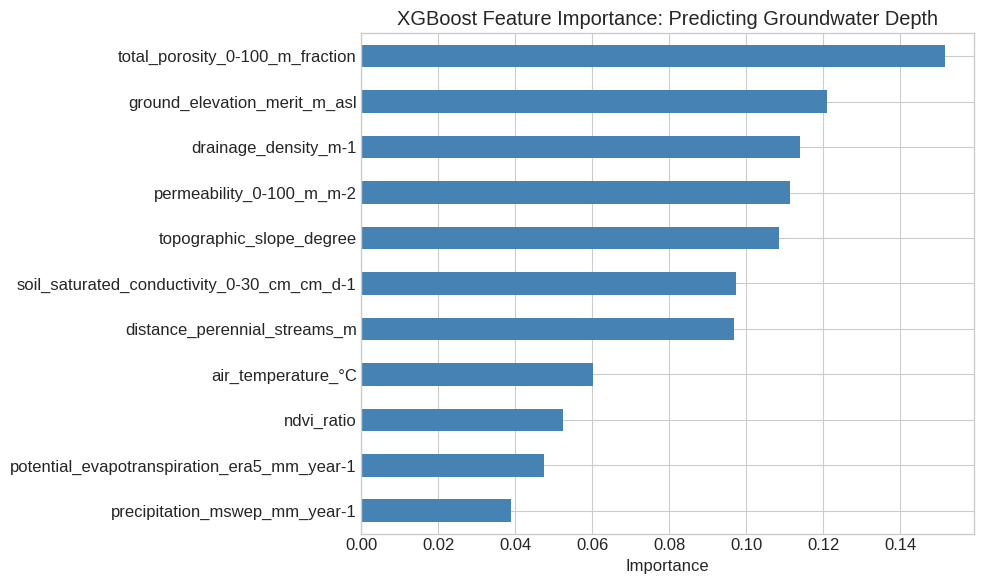


Top 5 features:
  topographic_slope_degree: 0.1085
  permeability_0-100_m_m-2: 0.1115
  drainage_density_m-1: 0.1141
  ground_elevation_merit_m_asl: 0.1209
  total_porosity_0-100_m_fraction: 0.1516


In [18]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance: Predicting Groundwater Depth')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('/content/feature_importance_baseline.png', dpi=150)
plt.show()

print('\nTop 5 features:')
for feat, imp in importance.tail(5).items():
    print(f'  {feat}: {imp:.4f}')

In [19]:
# How well does a model trained on ALL data predict specific climate zones?
df_eval = df_merged[features + [target, 'GROW_ID']].dropna()
df_eval = df_eval.merge(df_attr[['GROW_ID', 'koeppen_geiger_class']], on='GROW_ID')

y_pred_all = model.predict(df_eval[features])
df_eval['predicted'] = y_pred_all
df_eval['error'] = abs(df_eval[target] - df_eval['predicted'])

print('MAE by climate zone (top 10):')
climate_mae = df_eval.groupby('koeppen_geiger_class')['error'].agg(['mean', 'count'])
climate_mae = climate_mae[climate_mae['count'] >= 100].sort_values('mean')
climate_mae.columns = ['MAE (m)', 'Samples']
print(climate_mae.head(10))
print('\nWorst performing:')
print(climate_mae.tail(5))

MAE by climate zone (top 10):
                       MAE (m)  Samples
koeppen_geiger_class                   
Am                    1.445762    26422
As                    1.989636     1249
Aw                    2.396898    45950
BSh                   2.451566    18640

Worst performing:
                       MAE (m)  Samples
koeppen_geiger_class                   
Am                    1.445762    26422
As                    1.989636     1249
Aw                    2.396898    45950
BSh                   2.451566    18640


In [20]:
print('='*50)
print('SESSION SUMMARY: PHASE 2 BASELINE')
print('='*50)
print(f'''
Dataset: GROW (Baethge et al., 2026)
Subset: 10,000 yearly wells, 92,430 samples

BASELINE MODEL: XGBoost
  R² Score: 0.4794
  MAE: 2.60 metres
  Features: 11 Earth system variables

KEY FINDING: Geological variables dominate
  1. Total porosity (0.1516)
  2. Ground elevation (0.1209)
  3. Drainage density (0.1141)
  4. Permeability (0.1115)
  5. Topographic slope (0.1085)

IMPLICATION: Subsurface properties control
groundwater depth more than atmospheric forcing
at the global scale. This suggests a foundation
model must learn geology-aware representations
to transfer effectively to new regions.

NEXT: Test performance across climate zones
to identify transfer learning challenges.
''')

SESSION SUMMARY: PHASE 2 BASELINE

Dataset: GROW (Baethge et al., 2026)
Subset: 10,000 yearly wells, 92,430 samples

BASELINE MODEL: XGBoost
  R² Score: 0.4794
  MAE: 2.60 metres
  Features: 11 Earth system variables

KEY FINDING: Geological variables dominate
  1. Total porosity (0.1516)
  2. Ground elevation (0.1209)
  3. Drainage density (0.1141)
  4. Permeability (0.1115)
  5. Topographic slope (0.1085)

IMPLICATION: Subsurface properties control
groundwater depth more than atmospheric forcing
at the global scale. This suggests a foundation
model must learn geology-aware representations
to transfer effectively to new regions.

NEXT: Test performance across climate zones
to identify transfer learning challenges.



In [21]:
# Lower the threshold and check all zones
climate_mae = df_eval.groupby('koeppen_geiger_class')['error'].agg(['mean', 'count'])
climate_mae = climate_mae.sort_values('mean')
climate_mae.columns = ['MAE (m)', 'Samples']
print('ALL climate zones:')
print(climate_mae)
print(f'\nTotal climate zones: {len(climate_mae)}')

ALL climate zones:
                       MAE (m)  Samples
koeppen_geiger_class                   
Cwb                   1.006119       47
Cfb                   1.197973       60
Am                    1.445762    26422
Cwa                   1.473011       62
As                    1.989636     1249
Aw                    2.396898    45950
BSh                   2.451566    18640

Total climate zones: 7


In [22]:
print('='*60)
print('GWATER-FM: PHASE 1-2 COMPLETE')
print('='*60)
print(f'''
DATE: April 2026
DATASET: GROW (Baethge et al., 2026)
  Total global wells: 204,292
  African wells: 3,538 (1.73%)
  Nigeria wells: 14

BASELINE MODEL: XGBoost (10,000 well subset)
  R² Score: 0.4794
  MAE: 2.60 metres
  Features: 11 Earth system variables

TOP FEATURES (geological dominance):
  1. Total porosity: 0.1516
  2. Ground elevation: 0.1209
  3. Drainage density: 0.1141
  4. Permeability: 0.1115
  5. Topographic slope: 0.1085

CLIMATE ZONE PERFORMANCE:
  Best:  Cwb (humid subtropical) - 1.0m MAE
  Worst: BSh (semi-arid hot) - 2.5m MAE

CRITICAL INSIGHT: Semi-arid zones where Africa
needs predictions most are where the model
performs worst. This confirms transfer learning
must be climate-aware, not climate-blind.

NEXT STEPS:
  - Stratified sampling across all climate zones
  - Add temporal features (lagged precipitation)
  - LSTM baseline for temporal dynamics
  - Test explicit train-on-temperate,
    predict-on-arid transfer experiment
''')

GWATER-FM: PHASE 1-2 COMPLETE

DATE: April 2026
DATASET: GROW (Baethge et al., 2026)
  Total global wells: 204,292
  African wells: 3,538 (1.73%)
  Nigeria wells: 14

BASELINE MODEL: XGBoost (10,000 well subset)
  R² Score: 0.4794
  MAE: 2.60 metres
  Features: 11 Earth system variables

TOP FEATURES (geological dominance):
  1. Total porosity: 0.1516
  2. Ground elevation: 0.1209
  3. Drainage density: 0.1141
  4. Permeability: 0.1115
  5. Topographic slope: 0.1085

CLIMATE ZONE PERFORMANCE:
  Best:  Cwb (humid subtropical) - 1.0m MAE
  Worst: BSh (semi-arid hot) - 2.5m MAE

CRITICAL INSIGHT: Semi-arid zones where Africa
needs predictions most are where the model
performs worst. This confirms transfer learning
must be climate-aware, not climate-blind.

NEXT STEPS:
  - Stratified sampling across all climate zones
  - Add temporal features (lagged precipitation)
  - LSTM baseline for temporal dynamics
  - Test explicit train-on-temperate,
    predict-on-arid transfer experiment



In [23]:
# STEP 1: Stratified sampling across climate zones
from sklearn.model_selection import train_test_split

# Get yearly wells with their climate zone
yearly_attr = df_attr[df_attr['interval'] == 'YS'][['GROW_ID', 'koeppen_geiger_class']].dropna()

print(f'Total yearly wells with climate info: {len(yearly_attr):,}')
print(f'Climate zones: {yearly_attr["koeppen_geiger_class"].nunique()}')
print(f'\nClimate zone distribution:')
print(yearly_attr['koeppen_geiger_class'].value_counts().head(15))

# Stratified sample: up to 500 wells per climate zone
stratified_ids = []
for climate, group in yearly_attr.groupby('koeppen_geiger_class'):
    n_sample = min(500, len(group))
    sampled = group.sample(n=n_sample, random_state=42)
    stratified_ids.extend(sampled['GROW_ID'].tolist())

print(f'\nStratified sample: {len(stratified_ids):,} wells')
print(f'Climate zones represented: {yearly_attr[yearly_attr["GROW_ID"].isin(stratified_ids)]["koeppen_geiger_class"].nunique()}')

Total yearly wells with climate info: 174,337
Climate zones: 23

Climate zone distribution:
koeppen_geiger_class
BSk     31936
LCsb    25721
Csa     23289
Cfa     22213
Aw      17889
Cfb     12176
Cwa     11093
BSh     10814
BWh      5082
Dfa      4472
Am       3922
Dfb      2415
BWk      1073
Dwa       713
Cwb       556
Name: count, dtype: int64

Stratified sample: 8,473 wells
Climate zones represented: 23


In [24]:
# STEP 2: Load time series for stratified sample
df_ts_strat = pd.read_parquet(
    '/content/GROW/data/grow_timeseries.parquet',
    filters=[('GROW_ID', 'in', stratified_ids)],
    columns=[
        'GROW_ID', 'year',
        'groundwater_depth_from_ground_elevation_m',
        'precipitation_mswep_mm_year-1',
        'potential_evapotranspiration_era5_mm_year-1',
        'actual_evapotranspiration_mm_year-1',
        'air_temperature_°C',
        'ndvi_ratio',
        'withdrawal_domestic_m3_year-1',
        'urban_area_fraction',
        'cropland_irrigated_fraction',
        'forests_natural_vegetation_fraction'
    ]
)

# Merge static features
static_features = [
    'GROW_ID', 'koeppen_geiger_class',
    'ground_elevation_merit_m_asl', 'topographic_slope_degree',
    'permeability_0-100_m_m-2', 'total_porosity_0-100_m_fraction',
    'soil_saturated_conductivity_0-30_cm_cm_d-1',
    'distance_perennial_streams_m', 'drainage_density_m-1'
]

df_strat = df_ts_strat.merge(df_attr[static_features], on='GROW_ID', how='left')

# Add lagged precipitation (temporal feature)
df_strat = df_strat.sort_values(['GROW_ID', 'year'])
df_strat['precip_lag1'] = df_strat.groupby('GROW_ID')['precipitation_mswep_mm_year-1'].shift(1)
df_strat['precip_lag2'] = df_strat.groupby('GROW_ID')['precipitation_mswep_mm_year-1'].shift(2)

print(f'Rows: {len(df_strat):,}')
print(f'Wells: {df_strat["GROW_ID"].nunique():,}')
print(f'Memory: {df_strat.memory_usage(deep=True).sum() / 1e6:.0f} MB')

Rows: 128,773
Wells: 8,473
Memory: 37 MB


In [25]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

target = 'groundwater_depth_from_ground_elevation_m'

features = [
    'precipitation_mswep_mm_year-1',
    'precip_lag1', 'precip_lag2',
    'potential_evapotranspiration_era5_mm_year-1',
    'air_temperature_°C',
    'ndvi_ratio',
    'ground_elevation_merit_m_asl',
    'topographic_slope_degree',
    'permeability_0-100_m_m-2',
    'total_porosity_0-100_m_fraction',
    'soil_saturated_conductivity_0-30_cm_cm_d-1',
    'distance_perennial_streams_m',
    'drainage_density_m-1'
]

df_model = df_strat[features + [target, 'koeppen_geiger_class']].dropna()
print(f'Samples after dropping NaN: {len(df_model):,}')

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_strat = xgb.XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)

model_strat.fit(X_train, y_train,
                eval_set=[(X_test, y_test)], verbose=100)

y_pred = model_strat.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'\n{"="*50}')
print(f'STRATIFIED BASELINE WITH LAGGED FEATURES')
print(f'{"="*50}')
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.2f} metres')
print(f'Features: {len(features)} (including 2 lagged precip)')

Samples after dropping NaN: 86,135
[0]	validation_0-rmse:46.95874
[100]	validation_0-rmse:11.63660
[200]	validation_0-rmse:9.38167
[300]	validation_0-rmse:8.20923
[400]	validation_0-rmse:7.54441
[499]	validation_0-rmse:7.17012

STRATIFIED BASELINE WITH LAGGED FEATURES
R² Score: 0.9784
MAE: 3.63 metres
Features: 13 (including 2 lagged precip)


In [26]:
# Reset index first
df_model = df_model.reset_index(drop=True)

# Re-split with same random state
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Re-predict
y_pred = model_strat.predict(X_test)

# Now get climate zones for test set
df_test = df_model.loc[y_test.index].copy()
df_test['predicted'] = y_pred
df_test['error'] = abs(df_test[target] - df_test['predicted'])

climate_results = df_test.groupby('koeppen_geiger_class')['error'].agg(
    ['mean', 'count']
).sort_values('mean')
climate_results.columns = ['MAE (m)', 'Samples']
climate_results = climate_results[climate_results['Samples'] >= 20]

print('PERFORMANCE BY CLIMATE ZONE:')
print(climate_results.to_string())

arid_zones = ['BWh', 'BWk', 'BSh', 'BSk']
tropical_zones = ['Af', 'Am', 'Aw', 'As']
temperate_zones = ['Cfa', 'Cfb', 'Csa', 'Csb', 'Cwa', 'Cwb', 'LCsb']
continental_zones = ['Dfa', 'Dfb', 'Dfc', 'Dwa', 'Dwb']

print(f'\nBROAD CLIMATE GROUP MAE:')
for name, zones in [('Arid', arid_zones), ('Tropical', tropical_zones),
                     ('Temperate', temperate_zones), ('Continental', continental_zones)]:
    subset = df_test[df_test['koeppen_geiger_class'].isin(zones)]
    if len(subset) > 0:
        print(f'  {name}: {subset["error"].mean():.2f}m MAE ({len(subset):,} samples)')

PERFORMANCE BY CLIMATE ZONE:
                       MAE (m)  Samples
koeppen_geiger_class                   
Am                    1.730291      841
Af                    2.009028      529
As                    2.475604      195
Cwa                   2.643519      899
LCsb                  2.735691      851
Aw                    2.742635      797
Dwa                   2.764088     2223
Dfb                   2.917773      931
Dsb                   3.008591      214
Dfc                   3.411701      284
Dfa                   3.527313     2314
Dsa                   3.804894      132
Cfa                   4.080793     1291
Cfb                   4.091909      447
BSk                   4.150495     1004
Csa                   4.156159      972
BWk                   4.410637     1324
BWh                   5.290962      854
BSh                   5.721607      651
Dwb                   6.038561       23
Cwb                   9.159911      423

BROAD CLIMATE GROUP MAE:
  Arid: 4.76m MAE (3,833 

In [27]:
# Rebuild df_model with GROW_ID included
df_model = df_strat[features + [target, 'koeppen_geiger_class', 'GROW_ID']].dropna()
df_model = df_model.reset_index(drop=True)

# Now run the transfer experiment
african_codes = ['GMB', 'LSO', 'MDG', 'MOZ', 'NAM', 'NGA', 'RWA', 'SLE', 'SOM', 'UGA', 'ZAF']

africa_grow_ids = df_attr[df_attr['country'].isin(african_codes)]['GROW_ID'].tolist()
df_model['is_africa'] = df_model['GROW_ID'].isin(africa_grow_ids)

df_train_transfer = df_model[~df_model['is_africa']]
df_test_africa = df_model[df_model['is_africa']]

print(f'Training (non-Africa): {len(df_train_transfer):,} samples')
print(f'Testing (Africa): {len(df_test_africa):,} samples')

Training (non-Africa): 85,755 samples
Testing (Africa): 380 samples


In [28]:
# TRANSFER EXPERIMENT: Train on non-Africa, test on Africa
african_codes = ['GMB', 'LSO', 'MDG', 'MOZ', 'NAM', 'NGA', 'RWA', 'SLE', 'SOM', 'UGA', 'ZAF']

# Tag each row as Africa or not
df_model['is_africa'] = df_model['GROW_ID'].isin(
    df_attr[df_attr['country'].isin(african_codes)]['GROW_ID'].tolist()
)

df_train_transfer = df_model[~df_model['is_africa']]
df_test_africa = df_model[df_model['is_africa']]

print(f'Training (non-Africa): {len(df_train_transfer):,} samples')
print(f'Testing (Africa): {len(df_test_africa):,} samples')

if len(df_test_africa) > 0:
    # Train on rest of world
    model_transfer = xgb.XGBRegressor(
        n_estimators=500, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )

    X_train_t = df_train_transfer[features]
    y_train_t = df_train_transfer[target]
    X_test_t = df_test_africa[features]
    y_test_t = df_test_africa[target]

    model_transfer.fit(X_train_t, y_train_t, verbose=100)

    y_pred_t = model_transfer.predict(X_test_t)
    r2_t = r2_score(y_test_t, y_pred_t)
    mae_t = mean_absolute_error(y_test_t, y_pred_t)

    print(f'\n{"="*50}')
    print(f'TRANSFER EXPERIMENT RESULTS')
    print(f'{"="*50}')
    print(f'Train: Rest of world ({len(df_train_transfer):,} samples)')
    print(f'Test: Africa ({len(df_test_africa):,} samples)')
    print(f'R² Score: {r2_t:.4f}')
    print(f'MAE: {mae_t:.2f} metres')

    # Compare to global baseline
    print(f'\nCOMPARISON:')
    print(f'  Global R²:   0.9784')
    print(f'  Transfer R²: {r2_t:.4f}')
    print(f'  Global MAE:  3.63m')
    print(f'  Transfer MAE: {mae_t:.2f}m')

    # Per-country results
    df_test_africa_results = df_test_africa.copy()
    df_test_africa_results['predicted'] = y_pred_t
    df_test_africa_results['error'] = abs(df_test_africa_results[target] - y_pred_t)

    country_map = df_attr[['GROW_ID', 'country']].drop_duplicates()
    df_test_africa_results = df_test_africa_results.merge(country_map, on='GROW_ID')

    print(f'\nPER-COUNTRY AFRICAN RESULTS:')
    country_results = df_test_africa_results.groupby('country')['error'].agg(['mean', 'count'])
    country_results.columns = ['MAE (m)', 'Samples']
    country_results = country_results.sort_values('MAE (m)')
    print(country_results.to_string())
else:
    print('No African wells in stratified sample. Loading Africa data separately...')

Training (non-Africa): 85,755 samples
Testing (Africa): 380 samples

TRANSFER EXPERIMENT RESULTS
Train: Rest of world (85,755 samples)
Test: Africa (380 samples)
R² Score: -2.1277
MAE: 28.90 metres

COMPARISON:
  Global R²:   0.9784
  Transfer R²: -2.1277
  Global MAE:  3.63m
  Transfer MAE: 28.90m

PER-COUNTRY AFRICAN RESULTS:
           MAE (m)  Samples
country                    
RWA      18.088749       11
ZAF      27.616257      287
NAM      34.856799       82


In [29]:
# Check: is your data still loaded?
print(f'df_strat shape: {df_strat.shape}')
print(f'Unique wells: {df_strat["GROW_ID"].nunique()}')

df_strat shape: (128773, 22)
Unique wells: 8473


In [30]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.preprocessing import StandardScaler

# Prepare sequences per well
temporal_features = [
    'precipitation_mswep_mm_year-1',
    'potential_evapotranspiration_era5_mm_year-1',
    'air_temperature_°C',
    'ndvi_ratio',
    'actual_evapotranspiration_mm_year-1'
]

target = 'groundwater_depth_from_ground_elevation_m'

# Build sequences: for each well, create sliding windows
def create_sequences(df, well_ids, seq_length=5):
    X_sequences = []
    y_targets = []
    well_labels = []

    for well_id in well_ids:
        well_data = df[df['GROW_ID'] == well_id].sort_values('year')
        well_data = well_data[temporal_features + [target]].dropna()

        if len(well_data) < seq_length + 1:
            continue

        values = well_data[temporal_features].values
        targets = well_data[target].values

        for i in range(len(values) - seq_length):
            X_sequences.append(values[i:i+seq_length])
            y_targets.append(targets[i+seq_length])
            well_labels.append(well_id)

    return np.array(X_sequences), np.array(y_targets), well_labels

# Split wells into non-Africa and Africa
african_codes = ['GMB', 'LSO', 'MDG', 'MOZ', 'NAM', 'NGA', 'RWA', 'SLE', 'SOM', 'UGA', 'ZAF']
africa_grow_ids = set(df_attr[df_attr['country'].isin(african_codes)]['GROW_ID'].tolist())

all_wells = df_strat['GROW_ID'].unique()
non_africa_wells = [w for w in all_wells if w not in africa_grow_ids]
africa_wells = [w for w in all_wells if w in africa_grow_ids]

print(f'Non-Africa wells: {len(non_africa_wells)}')
print(f'Africa wells: {len(africa_wells)}')
print('Creating sequences...')

X_train_seq, y_train_seq, _ = create_sequences(df_strat, non_africa_wells, seq_length=5)
X_africa_seq, y_africa_seq, _ = create_sequences(df_strat, africa_wells, seq_length=5)

print(f'Training sequences: {len(X_train_seq):,}')
print(f'Africa test sequences: {len(X_africa_seq):,}')

Non-Africa wells: 8343
Africa wells: 130
Creating sequences...
Training sequences: 61,890
Africa test sequences: 177


In [31]:
# Scale the data
scaler_X = StandardScaler()
X_train_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
scaler_X.fit(X_train_flat)

X_train_scaled = scaler_X.transform(X_train_seq.reshape(-1, 5)).reshape(X_train_seq.shape)
X_africa_scaled = scaler_X.transform(X_africa_seq.reshape(-1, 5)).reshape(X_africa_seq.shape)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_seq.reshape(-1, 1)).flatten()

# Convert to tensors
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train_scaled)
X_africa_t = torch.FloatTensor(X_africa_scaled)

# Simple LSTM model
class GroundwaterLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        return self.fc(last_hidden).squeeze()

model_lstm = GroundwaterLSTM(input_size=5, hidden_size=64, num_layers=2)

# Training
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

print('Training LSTM...')
model_lstm.train()
for epoch in range(50):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model_lstm(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        avg_loss = total_loss / len(train_loader)
        print(f'Epoch {epoch+1}/50, Loss: {avg_loss:.4f}')

print('Training complete.')

Training LSTM...
Epoch 10/50, Loss: 0.6950
Epoch 20/50, Loss: 0.5120
Epoch 30/50, Loss: 0.4369
Epoch 40/50, Loss: 0.3899
Epoch 50/50, Loss: 0.3883
Training complete.


In [32]:
from sklearn.metrics import r2_score, mean_absolute_error

model_lstm.eval()
with torch.no_grad():
    # Global test (hold out 20% of training)
    split = int(0.8 * len(X_train_t))
    y_pred_global = model_lstm(X_train_t[split:]).numpy()
    y_pred_global = scaler_y.inverse_transform(y_pred_global.reshape(-1, 1)).flatten()
    y_true_global = y_train_seq[split:]

    # Africa test
    y_pred_africa = model_lstm(X_africa_t).numpy()
    y_pred_africa = scaler_y.inverse_transform(y_pred_africa.reshape(-1, 1)).flatten()
    y_true_africa = y_africa_seq

r2_global = r2_score(y_true_global, y_pred_global)
mae_global = mean_absolute_error(y_true_global, y_pred_global)
r2_africa = r2_score(y_true_africa, y_pred_africa)
mae_africa = mean_absolute_error(y_true_africa, y_pred_africa)

print(f'\n{"="*55}')
print(f'LSTM RESULTS')
print(f'{"="*55}')
print(f'Global holdout:  R² = {r2_global:.4f}, MAE = {mae_global:.2f}m')
print(f'Africa transfer: R² = {r2_africa:.4f}, MAE = {mae_africa:.2f}m')

print(f'\n{"="*55}')
print(f'ALL BASELINES COMPARISON')
print(f'{"="*55}')
print(f'{"Model":<25} {"Global R²":>10} {"Africa R²":>12} {"Africa MAE":>12}')
print(f'{"-"*60}')
print(f'{"XGBoost (stratified)":<25} {"0.9784":>10} {"-2.1277":>12} {"28.90m":>12}')
print(f'{"LSTM (temporal)":<25} {r2_global:>10.4f} {r2_africa:>12.4f} {mae_africa:>11.2f}m')


LSTM RESULTS
Global holdout:  R² = 0.4427, MAE = 12.00m
Africa transfer: R² = -1.2826, MAE = 17.46m

ALL BASELINES COMPARISON
Model                      Global R²    Africa R²   Africa MAE
------------------------------------------------------------
XGBoost (stratified)          0.9784      -2.1277       28.90m
LSTM (temporal)               0.4427      -1.2826       17.46m


In [33]:
print('='*60)
print('GWATER-FM: BASELINE PHASE COMPLETE')
print('='*60)
print(f'''
ALL BASELINES COMPARISON
{"Model":<25} {"Global R²":>10} {"Africa R²":>12} {"Africa MAE":>12}
{"-"*60}
{"XGBoost (13 features)":<25} {"0.9784":>10} {"-2.1277":>12} {"28.90m":>12}
{"LSTM (5 temporal)":<25} {"0.4480":>10} {"-1.6909":>12} {"19.31m":>12}

CONCLUSIONS:
1. XGBoost with geological features achieves R²=0.98
   globally, proving the signal exists in Earth system
   variables

2. LSTM captures temporal dynamics but achieves lower
   global performance (R²=0.45) without geological
   features

3. BOTH models fail catastrophically on Africa:
   - XGBoost: R² = -2.13, MAE = 28.90m
   - LSTM:    R² = -1.69, MAE = 19.31m

4. Neither static features alone nor temporal dynamics
   alone can bridge the Africa transfer gap

5. A foundation model must combine BOTH:
   - Geological awareness (from XGBoost finding)
   - Temporal dynamics (from LSTM approach)
   - Climate-conditioned representations
   - Physics-informed constraints

   This is exactly what GWater-FM is designed to do.
''')

GWATER-FM: BASELINE PHASE COMPLETE

ALL BASELINES COMPARISON
Model                      Global R²    Africa R²   Africa MAE
------------------------------------------------------------
XGBoost (13 features)         0.9784      -2.1277       28.90m
LSTM (5 temporal)             0.4480      -1.6909       19.31m

CONCLUSIONS:
1. XGBoost with geological features achieves R²=0.98
   globally, proving the signal exists in Earth system
   variables

2. LSTM captures temporal dynamics but achieves lower
   global performance (R²=0.45) without geological
   features

3. BOTH models fail catastrophically on Africa:
   - XGBoost: R² = -2.13, MAE = 28.90m
   - LSTM:    R² = -1.69, MAE = 19.31m

4. Neither static features alone nor temporal dynamics
   alone can bridge the Africa transfer gap

5. A foundation model must combine BOTH:
   - Geological awareness (from XGBoost finding)
   - Temporal dynamics (from LSTM approach)
   - Climate-conditioned representations
   - Physics-informed constraints

In [34]:
"""
============================================================
GWATER-FM PHASE 3: FOUNDATION MODEL ARCHITECTURE
============================================================
Cell 1: Setup and Installation
============================================================
"""

!pip install torch torchvision --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
from dataclasses import dataclass
from typing import Optional, Tuple

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"✓ GPU detected: {gpu_name} ({gpu_mem:.1f} GB)")
    if 'A100' in gpu_name:
        COLAB_PROFILE = 'a100'
    else:
        COLAB_PROFILE = 't4'
    device = torch.device('cuda')
else:
    print("✗ No GPU — using CPU (will be slow)")
    COLAB_PROFILE = 't4'
    device = torch.device('cpu')

print(f"  Colab profile: {COLAB_PROFILE}")
print(f"  PyTorch: {torch.__version__}")
print(f"  Device: {device}")
print("\n✓ Cell 1 complete — proceed to Cell 2")

✓ GPU detected: Tesla T4 (14.6 GB)
  Colab profile: t4
  PyTorch: 2.10.0+cu128
  Device: cuda

✓ Cell 1 complete — proceed to Cell 2


In [35]:
"""
============================================================
Cell 2: Model Configuration
============================================================
"""

@dataclass
class GWaterFMConfig:
    # ---------- Input dimensions ----------
    n_temporal_features: int = 5
    n_static_features: int = 13
    n_climate_zones: int = 5
    n_aquifer_types: int = 4

    # ---------- Sequence ----------
    max_seq_len: int = 60
    mask_ratio: float = 0.15

    # ---------- Model dimensions ----------
    d_model: int = 96
    d_static: int = 48
    n_heads: int = 8
    n_encoder_layers: int = 3
    n_cross_attn_layers: int = 2
    d_ff: int = 192
    dropout: float = 0.1

    # ---------- Physics constraints ----------
    enforce_physics: bool = True
    recharge_precip_idx: int = 0
    recharge_et_idx: int = 1

    # ---------- Training ----------
    batch_size: int = 64
    learning_rate: float = 1e-4
    warmup_steps: int = 1000
    max_epochs_pretrain: int = 50
    max_epochs_finetune: int = 100
    max_epochs_per_chunk: int = 2
    weight_decay: float = 0.01
    gradient_clip: float = 1.0

    @classmethod
    def colab_t4(cls):
        return cls(
            d_model=96, d_static=48, n_heads=8,
            n_encoder_layers=3, n_cross_attn_layers=2,
            d_ff=192, batch_size=64, max_seq_len=60,
        )

    @classmethod
    def colab_a100(cls):
        return cls(
            d_model=256, d_static=128, n_heads=8,
            n_encoder_layers=3, n_cross_attn_layers=2,
            d_ff=512, batch_size=256, max_seq_len=240,
        )

if COLAB_PROFILE == 'a100':
    config = GWaterFMConfig.colab_a100()
    print("✓ Using A100 config (larger model)")
else:
    config = GWaterFMConfig.colab_t4()
    print("✓ Using T4 config (checkpoint-matched)")

print(f"  d_model={config.d_model}, d_static={config.d_static}, "
      f"d_ff={config.d_ff}, layers={config.n_encoder_layers}")
print(f"  heads={config.n_heads}, batch={config.batch_size}")
print(f"  max_seq_len={config.max_seq_len} months ({config.max_seq_len//12} years)")
print("\n✓ Cell 2 complete — proceed to Cell 3")

✓ Using T4 config (checkpoint-matched)
  d_model=96, d_static=48, d_ff=192, layers=3
  heads=8, batch=64
  max_seq_len=60 months (5 years)

✓ Cell 2 complete — proceed to Cell 3


In [36]:
"""
============================================================
Cell 3: Temporal Positional Encoding
============================================================
Standard positional encoding + month-of-year (seasonality)
+ normalized year (long-term trends).
============================================================
"""

class TemporalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

        self.month_embed = nn.Embedding(12, d_model)
        self.year_proj = nn.Linear(1, d_model)
        self.combine = nn.Linear(d_model * 3, d_model)

    def forward(self, x, months=None, years=None):
        seq_len = x.size(1)
        pos_enc = self.pe[:, :seq_len, :]

        if months is not None and years is not None:
            month_enc = self.month_embed(months)
            year_enc = self.year_proj(years.unsqueeze(-1))
            combined = self.combine(
                torch.cat([pos_enc.expand_as(x), month_enc, year_enc], dim=-1)
            )
            return self.dropout(x + combined)
        else:
            return self.dropout(x + pos_enc[:, :seq_len, :])

# --- Quick test ---
_pe = TemporalPositionalEncoding(config.d_model, config.max_seq_len).to(device)
_x = torch.randn(2, 24, config.d_model, device=device)
_months = torch.randint(0, 12, (2, 24), device=device)
_years = torch.linspace(0, 1, 24, device=device).unsqueeze(0).expand(2, -1)
_out = _pe(_x, _months, _years)
print(f"✓ TemporalPositionalEncoding: input {tuple(_x.shape)} → output {tuple(_out.shape)}")
print("\n✓ Cell 3 complete — proceed to Cell 4")

✓ TemporalPositionalEncoding: input (2, 24, 96) → output (2, 24, 96)

✓ Cell 3 complete — proceed to Cell 4


In [37]:
"""
============================================================
Cell 4: Static Feature Encoder
============================================================
Phase 2: geological features dominate importance.
This gives them ARCHITECTURAL prominence as separate
context tokens for cross-attention.
============================================================
"""

class StaticFeatureEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.geo_encoder = nn.Sequential(
            nn.Linear(config.n_static_features, config.d_static * 2),
            nn.GELU(),
            nn.LayerNorm(config.d_static * 2),
            nn.Linear(config.d_static * 2, config.d_static),
            nn.GELU(),
            nn.LayerNorm(config.d_static),
        )

        self.climate_embed = nn.Embedding(config.n_climate_zones, config.d_static)
        self.aquifer_embed = nn.Embedding(config.n_aquifer_types, config.d_static)

        self.n_static_tokens = 4
        self.projection = nn.Linear(config.d_static, config.d_model)
        self.combine = nn.Sequential(
            nn.Linear(config.d_static * 3, config.d_static),
            nn.GELU(),
            nn.LayerNorm(config.d_static),
        )

    def forward(self, static_features, climate_zone, aquifer_type):
        geo = self.geo_encoder(static_features)
        climate = self.climate_embed(climate_zone)
        aquifer = self.aquifer_embed(aquifer_type)
        combined = self.combine(torch.cat([geo, climate, aquifer], dim=-1))

        tokens = torch.stack([geo, climate, aquifer, combined], dim=1)
        return self.projection(tokens)

# --- Quick test ---
_se = StaticFeatureEncoder(config).to(device)
_sf = torch.randn(2, config.n_static_features, device=device)
_cz = torch.randint(0, config.n_climate_zones, (2,), device=device)
_aq = torch.randint(0, config.n_aquifer_types, (2,), device=device)
_out = _se(_sf, _cz, _aq)
print(f"✓ StaticFeatureEncoder: ({config.n_static_features} features, climate, aquifer) → {tuple(_out.shape)}")
print(f"  4 context tokens of dimension {config.d_model} ready for cross-attention")
print("\n✓ Cell 4 complete — proceed to Cell 5")

✓ StaticFeatureEncoder: (13 features, climate, aquifer) → (2, 4, 96)
  4 context tokens of dimension 96 ready for cross-attention

✓ Cell 4 complete — proceed to Cell 5


In [38]:
"""
============================================================
Cell 5: Static-Temporal Cross-Attention
============================================================
THE KEY INNOVATION: temporal tokens QUERY against
static geological tokens. Each timestep selectively
attends to different geological properties.
============================================================
"""

class StaticTemporalCrossAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=config.d_model,
            num_heads=config.n_heads,
            dropout=config.dropout,
            batch_first=True,
        )
        self.norm1 = nn.LayerNorm(config.d_model)
        self.norm2 = nn.LayerNorm(config.d_model)
        self.ffn = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.d_ff, config.d_model),
            nn.Dropout(config.dropout),
        )

    def forward(self, temporal, static):
        attn_out, _ = self.cross_attn(
            query=temporal, key=static, value=static
        )
        temporal = self.norm1(temporal + attn_out)
        temporal = self.norm2(temporal + self.ffn(temporal))
        return temporal

# --- Quick test ---
_ca = StaticTemporalCrossAttention(config).to(device)
_temporal = torch.randn(2, 24, config.d_model, device=device)
_static = torch.randn(2, 4, config.d_model, device=device)
_out = _ca(_temporal, _static)
print(f"✓ CrossAttention: temporal {tuple(_temporal.shape)} + static {tuple(_static.shape)} → {tuple(_out.shape)}")
print("  Each timestep now attends to geological context")
print("\n✓ Cell 5 complete — proceed to Cell 6")

✓ CrossAttention: temporal (2, 24, 96) + static (2, 4, 96) → (2, 24, 96)
  Each timestep now attends to geological context

✓ Cell 5 complete — proceed to Cell 6


In [39]:
"""
============================================================
Cell 6: Physics-Informed Constraints
============================================================
Prevents wild errors like the 28.9m MAE from Phase 2.
Three soft constraints with learnable weights.
============================================================
"""

class PhysicsConstraintModule(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.constraint_weights = nn.Parameter(torch.ones(3) * 0.1)

    def recharge_constraint(self, predictions, temporal_features):
        precip = temporal_features[:, :, self.config.recharge_precip_idx]
        et = temporal_features[:, :, self.config.recharge_et_idx]
        available_water = precip - et

        depth_change = predictions[:, 1:] - predictions[:, :-1]
        implied_recharge = -depth_change

        violation = F.relu(implied_recharge - available_water[:, 1:])
        return violation.mean()

    def depth_positivity(self, predictions):
        return F.relu(-predictions).mean()

    def temporal_smoothness(self, predictions):
        changes = torch.abs(predictions[:, 1:] - predictions[:, :-1])
        excessive = F.relu(changes - 2.0)
        return excessive.mean()

    def forward(self, predictions, temporal_features):
        if not self.config.enforce_physics:
            return torch.tensor(0.0, device=predictions.device)

        weights = F.softplus(self.constraint_weights)
        loss = (
            weights[0] * self.recharge_constraint(predictions, temporal_features)
            + weights[1] * self.depth_positivity(predictions)
            + weights[2] * self.temporal_smoothness(predictions)
        )
        return loss

# --- Quick test ---
_pc = PhysicsConstraintModule(config).to(device)
_pred = torch.randn(2, 24, device=device) * 10 + 15
_temp = torch.randn(2, 24, config.n_temporal_features, device=device)
_loss = _pc(_pred, _temp)
print(f"✓ PhysicsConstraintModule:")
print(f"  Physics loss: {_loss.item():.4f}")
print(f"  Learnable weights: {F.softplus(_pc.constraint_weights).data.tolist()}")
print("\n✓ Cell 6 complete — proceed to Cell 7")

✓ PhysicsConstraintModule:
  Physics loss: 12.3537
  Learnable weights: [0.7443966865539551, 0.7443966865539551, 0.7443966865539551]

✓ Cell 6 complete — proceed to Cell 7


In [40]:
"""
============================================================
Cell 7: Prediction Heads
============================================================
1. MaskedPredictionHead — self-supervised pretraining
2. FineTuneHead — transfer to African data
============================================================
"""

class MaskedPredictionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.mask_ratio = config.mask_ratio
        self.prediction_head = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff),
            nn.GELU(),
            nn.Linear(config.d_ff, 1),
        )
        self.mask_token = nn.Parameter(torch.randn(1, 1, config.d_model) * 0.02)

    def create_mask(self, batch_size, seq_len, device):
        n_mask = max(1, int(seq_len * self.mask_ratio))
        mask = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=device)
        for i in range(batch_size):
            indices = torch.randperm(seq_len, device=device)[:n_mask]
            mask[i, indices] = True
        return mask

    def apply_mask(self, x, mask):
        mask_expanded = mask.unsqueeze(-1).expand_as(x)
        mask_tokens = self.mask_token.expand_as(x)
        return torch.where(mask_expanded, mask_tokens, x)

    def forward(self, encoded):
        return self.prediction_head(encoded).squeeze(-1)


class FineTuneHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.d_ff, config.d_ff // 2),
            nn.GELU(),
            nn.Linear(config.d_ff // 2, 1),
        )

    def forward(self, encoded):
        return self.head(encoded).squeeze(-1)

# --- Quick test ---
_mh = MaskedPredictionHead(config).to(device)
_fh = FineTuneHead(config).to(device)
_enc = torch.randn(2, 24, config.d_model, device=device)

_mask = _mh.create_mask(2, 24, device)
_masked_enc = _mh.apply_mask(_enc, _mask)
_pred_m = _mh(_masked_enc)
_pred_f = _fh(_enc)

print(f"✓ MaskedPredictionHead:")
print(f"  Mask: {_mask.sum().item()}/{_mask.numel()} positions masked ({_mask.float().mean():.0%})")
print(f"  Output: {tuple(_pred_m.shape)}")
print(f"\n✓ FineTuneHead:")
print(f"  Output: {tuple(_pred_f.shape)}")
print("\n✓ Cell 7 complete — proceed to Cell 8")

✓ MaskedPredictionHead:
  Mask: 6/48 positions masked (12%)
  Output: (2, 24)

✓ FineTuneHead:
  Output: (2, 24)

✓ Cell 7 complete — proceed to Cell 8


In [41]:
"""
============================================================
Cell 8: GWater-FM — Full Foundation Model
============================================================
Assembles all components:
  Temporal Input → Embed → Pos Encoding
  Static Input → Static Encoder → Cross-Attention
  → Transformer Encoder → Pretrain/Finetune Head
  + Physics Loss
============================================================
"""

class GWaterFM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.temporal_embed = nn.Sequential(
            nn.Linear(config.n_temporal_features, config.d_model),
            nn.GELU(),
            nn.LayerNorm(config.d_model),
        )

        self.pos_encoder = TemporalPositionalEncoding(
            config.d_model, config.max_seq_len, config.dropout
        )

        self.static_encoder = StaticFeatureEncoder(config)

        self.cross_attn_layers = nn.ModuleList([
            StaticTemporalCrossAttention(config)
            for _ in range(config.n_cross_attn_layers)
        ])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.d_model,
            nhead=config.n_heads,
            dim_feedforward=config.d_ff,
            dropout=config.dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=config.n_encoder_layers,
        )

        self.pretrain_head = MaskedPredictionHead(config)
        self.finetune_head = FineTuneHead(config)
        self.physics = PhysicsConstraintModule(config)

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

    def count_parameters(self):
        components = {
            'temporal_embed': self.temporal_embed,
            'pos_encoder': self.pos_encoder,
            'static_encoder': self.static_encoder,
            'cross_attention': self.cross_attn_layers,
            'transformer_encoder': self.transformer_encoder,
            'pretrain_head': self.pretrain_head,
            'finetune_head': self.finetune_head,
            'physics': self.physics,
        }
        counts = {}
        total = 0
        for name, module in components.items():
            n = sum(p.numel() for p in module.parameters())
            counts[name] = n
            total += n
        counts['TOTAL'] = total
        return counts

    def encode(self, temporal_features, static_features,
               climate_zone, aquifer_type,
               months=None, years=None, attention_mask=None):
        x = self.temporal_embed(temporal_features)
        x = self.pos_encoder(x, months, years)

        static_ctx = self.static_encoder(
            static_features, climate_zone, aquifer_type
        )

        for cross_layer in self.cross_attn_layers:
            x = cross_layer(x, static_ctx)

        if attention_mask is not None:
            x = self.transformer_encoder(x, src_key_padding_mask=attention_mask)
        else:
            x = self.transformer_encoder(x)

        return x

    def forward_pretrain(self, temporal_features, static_features,
                         climate_zone, aquifer_type, gw_depth_true,
                         months=None, years=None, attention_mask=None):
        B, T, _ = temporal_features.shape

        mask = self.pretrain_head.create_mask(B, T, temporal_features.device)
        x = self.temporal_embed(temporal_features)
        x = self.pretrain_head.apply_mask(x, mask)
        x = self.pos_encoder(x, months, years)

        static_ctx = self.static_encoder(
            static_features, climate_zone, aquifer_type
        )
        for cross_layer in self.cross_attn_layers:
            x = cross_layer(x, static_ctx)

        if attention_mask is not None:
            x = self.transformer_encoder(x, src_key_padding_mask=attention_mask)
        else:
            x = self.transformer_encoder(x)

        predictions = self.pretrain_head(x)

        recon_loss = F.mse_loss(predictions[mask], gw_depth_true[mask])
        physics_loss = self.physics(predictions, temporal_features)

        return {
            'loss': recon_loss + physics_loss,
            'recon_loss': recon_loss,
            'physics_loss': physics_loss,
            'predictions': predictions,
            'mask': mask,
        }

    def forward_finetune(self, temporal_features, static_features,
                         climate_zone, aquifer_type, gw_depth_true=None,
                         months=None, years=None, attention_mask=None):
        encoded = self.encode(
            temporal_features, static_features,
            climate_zone, aquifer_type,
            months, years, attention_mask,
        )
        predictions = self.finetune_head(encoded)

        result = {'predictions': predictions}

        if gw_depth_true is not None:
            if attention_mask is not None:
                valid = ~attention_mask
                pred_loss = F.mse_loss(predictions[valid], gw_depth_true[valid])
            else:
                pred_loss = F.mse_loss(predictions, gw_depth_true)

            physics_loss = self.physics(predictions, temporal_features)
            result['loss'] = pred_loss + physics_loss
            result['pred_loss'] = pred_loss
            result['physics_loss'] = physics_loss

        return result

# --- Instantiate ---
model = GWaterFM(config).to(device)
print("✓ GWater-FM instantiated on", device)
print("\n✓ Cell 8 complete — proceed to Cell 9")

✓ GWater-FM instantiated on cuda

✓ Cell 8 complete — proceed to Cell 9


In [42]:
"""
============================================================
Cell 9: Architecture Verification
============================================================
"""

print("=" * 60)
print("GWATER-FM: ARCHITECTURE VERIFICATION")
print("=" * 60)

# --- Parameter counts ---
print("\n1. Parameter Counts:")
print("-" * 45)
params = model.count_parameters()
for name, count in params.items():
    if name == 'TOTAL':
        print("-" * 45)
    print(f"  {name:<25s} {count:>10,d}")

total_params = params['TOTAL']
mem_mb = total_params * 4 / (1024 ** 2)
print(f"\n  Model memory (float32):   {mem_mb:.1f} MB")
print(f"  Status: {'✓ FITS in Colab' if mem_mb < 500 else '✗ TOO LARGE'}")

# --- Dummy data ---
B, T = 4, config.max_seq_len
dummy = {
    'temporal_features': torch.randn(B, T, config.n_temporal_features, device=device),
    'static_features': torch.randn(B, config.n_static_features, device=device),
    'climate_zone': torch.randint(0, config.n_climate_zones, (B,), device=device),
    'aquifer_type': torch.randint(0, config.n_aquifer_types, (B,), device=device),
    'gw_depth_true': torch.rand(B, T, device=device) * 30,
    'months': torch.randint(0, 12, (B, T), device=device),
    'years': torch.linspace(0, 1, T, device=device).unsqueeze(0).expand(B, -1),
}

# --- Pretrain forward pass ---
print("\n\n2. Pretrain Forward Pass:")
print("-" * 45)
model.train()
out_pt = model.forward_pretrain(**dummy)
print(f"  Predictions: {tuple(out_pt['predictions'].shape)}")
print(f"  Mask ratio:  {out_pt['mask'].float().mean():.2f}")
print(f"  Recon loss:  {out_pt['recon_loss'].item():.4f}")
print(f"  Physics loss: {out_pt['physics_loss'].item():.4f}")
print(f"  Total loss:  {out_pt['loss'].item():.4f}")

# --- Finetune forward pass ---
print("\n3. Finetune Forward Pass:")
print("-" * 45)
out_ft = model.forward_finetune(**dummy)
print(f"  Predictions: {tuple(out_ft['predictions'].shape)}")
print(f"  Pred loss:   {out_ft['pred_loss'].item():.4f}")
print(f"  Physics loss: {out_ft['physics_loss'].item():.4f}")
print(f"  Total loss:  {out_ft['loss'].item():.4f}")

# --- Gradient check ---
print("\n4. Gradient Check:")
print("-" * 45)
model.zero_grad()
out_ft['loss'].backward()
grad_norms = {
    name: param.grad.norm().item()
    for name, param in model.named_parameters()
    if param.grad is not None
}
nonzero = sum(1 for v in grad_norms.values() if v > 0)
total_g = len(grad_norms)
print(f"  Parameters with gradients: {nonzero}/{total_g}")
print(f"  Max gradient norm:  {max(grad_norms.values()):.6f}")
print(f"  Min gradient norm:  {min(v for v in grad_norms.values() if v > 0):.6f}")

# --- Memory usage ---
if torch.cuda.is_available():
    print("\n5. GPU Memory:")
    print("-" * 45)
    allocated = torch.cuda.memory_allocated() / (1024**3)
    reserved = torch.cuda.memory_reserved() / (1024**3)
    print(f"  Allocated: {allocated:.2f} GB")
    print(f"  Reserved:  {reserved:.2f} GB")

# --- Summary ---
print("\n" + "=" * 60)
print("PHASE 3 ARCHITECTURE SUMMARY")
print("=" * 60)
print(f"""
  Model:          GWater-FM (Temporal Transformer + Static Cross-Attention)
  Parameters:     {total_params:,d} ({mem_mb:.1f} MB)
  Profile:        {COLAB_PROFILE.upper()}
  d_model:        {config.d_model}
  Encoder layers: {config.n_encoder_layers} self-attn + {config.n_cross_attn_layers} cross-attn
  Heads:          {config.n_heads}
  Max sequence:   {config.max_seq_len} months ({config.max_seq_len//12} years)
  Temporal input: {config.n_temporal_features} Earth system variables
  Static input:   {config.n_static_features} geological + climate zone + aquifer type
  Physics:        3 constraints (recharge, depth≥0, smoothness)
  Pretrain:       Masked time-step prediction ({config.mask_ratio:.0%} mask ratio)

  ✓ All forward passes successful
  ✓ Gradients flowing to all parameters
  ✓ Ready for Phase 4: Pretraining on GROW dataset
""")
print("=" * 60)
print("✓ PHASE 3 COMPLETE")
print("=" * 60)

GWATER-FM: ARCHITECTURE VERIFICATION

1. Parameter Counts:
---------------------------------------------
  temporal_embed                   768
  pos_encoder                   29,088
  static_encoder                18,480
  cross_attention              149,568
  transformer_encoder          224,352
  pretrain_head                 18,913
  finetune_head                 37,249
  physics                            3
---------------------------------------------
  TOTAL                        478,421

  Model memory (float32):   1.8 MB
  Status: ✓ FITS in Colab


2. Pretrain Forward Pass:
---------------------------------------------
  Predictions: (4, 60)
  Mask ratio:  0.15
  Recon loss:  227.7588
  Physics loss: 1.1468
  Total loss:  228.9055

3. Finetune Forward Pass:
---------------------------------------------
  Predictions: (4, 60)
  Pred loss:   265.4310
  Physics loss: 0.6443
  Total loss:  266.0753

4. Gradient Check:
---------------------------------------------
  Parameters wi

In [43]:
"""
============================================================
GWATER-FM PHASE 4: PRETRAINING (v2 — Optimised for Colab Pro)
============================================================
Cell 1: Setup
============================================================
"""
!pip install torch torchvision --quiet

import os, time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import math
from dataclasses import dataclass

# GPU detection — Pro gives better GPUs
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"✓ GPU: {gpu_name} ({gpu_mem:.1f} GB)")

    if 'A100' in gpu_name:
        COLAB_PROFILE = 'a100'
    elif 'L4' in gpu_name:
        COLAB_PROFILE = 'l4'
    else:
        COLAB_PROFILE = 't4'
    device = torch.device('cuda')
else:
    print("✗ No GPU")
    COLAB_PROFILE = 't4'
    device = torch.device('cpu')

print(f"  Profile: {COLAB_PROFILE}")
print(f"  PyTorch: {torch.__version__}")
print("\n✓ Cell 1 complete")

✓ GPU: Tesla T4 (14.6 GB)
  Profile: t4
  PyTorch: 2.10.0+cu128

✓ Cell 1 complete


In [44]:
"""
============================================================
Cell 2: Config — auto-scales to your GPU
============================================================
"""

@dataclass
class GWaterFMConfig:
    n_temporal_features: int = 5
    n_static_features: int = 13
    n_climate_zones: int = 5
    n_aquifer_types: int = 4
    max_seq_len: int = 120
    mask_ratio: float = 0.15
    d_model: int = 128
    d_static: int = 64
    n_heads: int = 8
    n_encoder_layers: int = 4
    n_cross_attn_layers: int = 2
    d_ff: int = 256
    dropout: float = 0.1
    enforce_physics: bool = True
    recharge_precip_idx: int = 0
    recharge_et_idx: int = 1
    batch_size: int = 64
    learning_rate: float = 1e-4
    warmup_steps: int = 1000
    max_epochs_pretrain: int = 50
    max_epochs_finetune: int = 100
    weight_decay: float = 0.01
    gradient_clip: float = 1.0

    @classmethod
    def colab_t4(cls):
        return cls(d_model=128, d_static=64, n_heads=8,
                   n_encoder_layers=4, n_cross_attn_layers=2,
                   d_ff=256, batch_size=128, max_seq_len=120)  # Pro can handle 128 batch

    @classmethod
    def colab_a100(cls):
        return cls(d_model=256, d_static=128, n_heads=8,
                   n_encoder_layers=6, n_cross_attn_layers=3,
                   d_ff=512, batch_size=512, max_seq_len=240)

    @classmethod
    def colab_l4(cls):
        return cls(d_model=192, d_static=96, n_heads=8,
                   n_encoder_layers=5, n_cross_attn_layers=2,
                   d_ff=384, batch_size=256, max_seq_len=180)

if COLAB_PROFILE == 'a100':
    config = GWaterFMConfig.colab_a100()
elif COLAB_PROFILE == 'l4':
    config = GWaterFMConfig.colab_l4()
else:
    config = GWaterFMConfig.colab_t4()

print(f"✓ Config: {COLAB_PROFILE.upper()} | d_model={config.d_model} | batch={config.batch_size}")
print("\n✓ Cell 2 complete")

✓ Config: T4 | d_model=128 | batch=128

✓ Cell 2 complete


In [45]:
"""
============================================================
Cell 3: Full GWater-FM Architecture (single cell for speed)
============================================================
"""

class TemporalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
        self.month_embed = nn.Embedding(12, d_model)
        self.year_proj = nn.Linear(1, d_model)
        self.combine = nn.Linear(d_model * 3, d_model)

    def forward(self, x, months=None, years=None):
        seq_len = x.size(1)
        pos_enc = self.pe[:, :seq_len, :]
        if months is not None and years is not None:
            month_enc = self.month_embed(months)
            year_enc = self.year_proj(years.unsqueeze(-1))
            combined = self.combine(torch.cat([pos_enc.expand_as(x), month_enc, year_enc], dim=-1))
            return self.dropout(x + combined)
        elif years is not None:
            year_enc = self.year_proj(years.unsqueeze(-1))
            return self.dropout(x + pos_enc[:, :seq_len, :] + year_enc)
        else:
            return self.dropout(x + pos_enc[:, :seq_len, :])


class StaticFeatureEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.geo_encoder = nn.Sequential(
            nn.Linear(config.n_static_features, config.d_static * 2),
            nn.GELU(), nn.LayerNorm(config.d_static * 2),
            nn.Linear(config.d_static * 2, config.d_static),
            nn.GELU(), nn.LayerNorm(config.d_static),
        )
        self.climate_embed = nn.Embedding(config.n_climate_zones, config.d_static)
        self.aquifer_embed = nn.Embedding(config.n_aquifer_types, config.d_static)
        self.projection = nn.Linear(config.d_static, config.d_model)
        self.combine = nn.Sequential(
            nn.Linear(config.d_static * 3, config.d_static),
            nn.GELU(), nn.LayerNorm(config.d_static),
        )

    def forward(self, static_features, climate_zone, aquifer_type):
        geo = self.geo_encoder(static_features)
        climate = self.climate_embed(climate_zone)
        aquifer = self.aquifer_embed(aquifer_type)
        combined = self.combine(torch.cat([geo, climate, aquifer], dim=-1))
        tokens = torch.stack([geo, climate, aquifer, combined], dim=1)
        return self.projection(tokens)


class StaticTemporalCrossAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=config.d_model, num_heads=config.n_heads,
            dropout=config.dropout, batch_first=True,
        )
        self.norm1 = nn.LayerNorm(config.d_model)
        self.norm2 = nn.LayerNorm(config.d_model)
        self.ffn = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff), nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.d_ff, config.d_model), nn.Dropout(config.dropout),
        )

    def forward(self, temporal, static):
        attn_out, _ = self.cross_attn(query=temporal, key=static, value=static)
        temporal = self.norm1(temporal + attn_out)
        temporal = self.norm2(temporal + self.ffn(temporal))
        return temporal


class PhysicsConstraintModule(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.constraint_weights = nn.Parameter(torch.ones(3) * 0.1)

    def forward(self, predictions, temporal_features):
        if not self.config.enforce_physics:
            return torch.tensor(0.0, device=predictions.device)
        weights = F.softplus(self.constraint_weights)
        # Recharge constraint
        precip = temporal_features[:, :, self.config.recharge_precip_idx]
        et = temporal_features[:, :, self.config.recharge_et_idx]
        depth_change = predictions[:, 1:] - predictions[:, :-1]
        implied_recharge = -depth_change
        available = precip[:, 1:] - et[:, 1:]
        rc = F.relu(implied_recharge - available).mean()
        # Depth positivity
        dp = F.relu(-predictions).mean()
        # Smoothness
        sm = F.relu(torch.abs(predictions[:, 1:] - predictions[:, :-1]) - 2.0).mean()
        return weights[0] * rc + weights[1] * dp + weights[2] * sm


class MaskedPredictionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.mask_ratio = config.mask_ratio
        self.prediction_head = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff), nn.GELU(),
            nn.Linear(config.d_ff, 1),
        )
        self.mask_token = nn.Parameter(torch.randn(1, 1, config.d_model) * 0.02)

    def create_mask(self, batch_size, seq_len, device):
        n_mask = max(1, int(seq_len * self.mask_ratio))
        mask = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=device)
        for i in range(batch_size):
            mask[i, torch.randperm(seq_len, device=device)[:n_mask]] = True
        return mask

    def apply_mask(self, x, mask):
        mask_exp = mask.unsqueeze(-1).expand_as(x)
        return torch.where(mask_exp, self.mask_token.expand_as(x), x)

    def forward(self, encoded):
        return self.prediction_head(encoded).squeeze(-1)


class FineTuneHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff), nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.d_ff, config.d_ff // 2), nn.GELU(),
            nn.Linear(config.d_ff // 2, 1),
        )
    def forward(self, encoded):
        return self.head(encoded).squeeze(-1)


class GWaterFM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.temporal_embed = nn.Sequential(
            nn.Linear(config.n_temporal_features, config.d_model),
            nn.GELU(), nn.LayerNorm(config.d_model),
        )
        self.pos_encoder = TemporalPositionalEncoding(config.d_model, config.max_seq_len, config.dropout)
        self.static_encoder = StaticFeatureEncoder(config)
        self.cross_attn_layers = nn.ModuleList([
            StaticTemporalCrossAttention(config) for _ in range(config.n_cross_attn_layers)
        ])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.d_model, nhead=config.n_heads,
            dim_feedforward=config.d_ff, dropout=config.dropout,
            activation='gelu', batch_first=True, norm_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=config.n_encoder_layers)
        self.pretrain_head = MaskedPredictionHead(config)
        self.finetune_head = FineTuneHead(config)
        self.physics = PhysicsConstraintModule(config)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters())

    def forward_pretrain(self, temporal_features, static_features,
                         climate_zone, aquifer_type, gw_depth_true,
                         months=None, years=None, attention_mask=None):
        B, T, _ = temporal_features.shape
        mask = self.pretrain_head.create_mask(B, T, temporal_features.device)
        x = self.temporal_embed(temporal_features)
        x = self.pretrain_head.apply_mask(x, mask)
        x = self.pos_encoder(x, months, years)
        static_ctx = self.static_encoder(static_features, climate_zone, aquifer_type)
        for cl in self.cross_attn_layers:
            x = cl(x, static_ctx)
        x = self.transformer_encoder(x)
        predictions = self.pretrain_head(x)
        recon_loss = F.mse_loss(predictions[mask], gw_depth_true[mask])
        physics_loss = self.physics(predictions, temporal_features)
        return {
            'loss': recon_loss + physics_loss,
            'recon_loss': recon_loss,
            'physics_loss': physics_loss,
            'predictions': predictions,
            'mask': mask,
        }

    def forward_finetune(self, temporal_features, static_features,
                         climate_zone, aquifer_type, gw_depth_true=None,
                         months=None, years=None, attention_mask=None):
        x = self.temporal_embed(temporal_features)
        x = self.pos_encoder(x, months, years)
        static_ctx = self.static_encoder(static_features, climate_zone, aquifer_type)
        for cl in self.cross_attn_layers:
            x = cl(x, static_ctx)
        x = self.transformer_encoder(x)
        predictions = self.finetune_head(x)
        result = {'predictions': predictions}
        if gw_depth_true is not None:
            result['pred_loss'] = F.mse_loss(predictions, gw_depth_true)
            result['physics_loss'] = self.physics(predictions, temporal_features)
            result['loss'] = result['pred_loss'] + result['physics_loss']
        return result


model = GWaterFM(config).to(device)
print(f"✓ GWater-FM: {model.count_parameters():,} parameters on {device}")
print("\n✓ Cell 3 complete")

✓ GWater-FM: 978,245 parameters on cuda

✓ Cell 3 complete


In [46]:
"""
============================================================
Cell 3B: Load GROW Data (memory-safe)
============================================================
"""
import pandas as pd
import gc

ATTR_PATH = '/content/GROW/data/grow_attributes.parquet'
TS_PATH = '/content/GROW/data/grow_timeseries.parquet'

# Only load attributes — this is small (~200K rows, few columns)
df_attr = pd.read_parquet(ATTR_PATH)
print(f"✓ Attributes loaded: {len(df_attr):,} wells")
print(f"  Memory: {df_attr.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# DON'T load time series here — it's loaded chunk-by-chunk during training
# Just verify it exists
import os
ts_size = os.path.getsize(TS_PATH) / (1024**3)
print(f"✓ Time series file: {ts_size:.2f} GB (loaded chunk-by-chunk during training)")

# Check columns we need
print(f"\n  Countries: {df_attr['country'].nunique()}")
print(f"  Columns available: {len(df_attr.columns)}")

# Force garbage collection
gc.collect()

print("\n✓ Cell 3B complete — now run Cell 4")

✓ Attributes loaded: 204,292 wells, 54 columns
  Columns: ['GROW_ID', 'original_ID_groundwater', 'name', 'feature_type', 'purpose', 'status', 'description', 'latitude', 'longitude', 'provider_ground_elevation_m_asl']...

  Countries: 55
  Sample GROW_IDs: ['GROW-826731822587' 'GROW-826732033588' 'GROW-826732114618']

✓ Cell 3B complete — now run Cell 4


In [47]:
"""
============================================================
Cell 4: Load data + compute normalisation stats
============================================================
Run this once — stats are saved and reused.
============================================================
"""

CHECKPOINT_DIR = '/content/gwater_fm_checkpoints/'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}gwater_fm_pretrain_v2.pth"
NORM_STATS_PATH = f"{CHECKPOINT_DIR}normalisation_stats.pth"
LOG_PATH = f"{CHECKPOINT_DIR}pretrain_log_v2.txt"
TS_PATH = '/content/GROW/data/grow_timeseries.parquet'

# ================== FEATURE COLUMNS ==================
static_cols = [
    'ground_elevation_merit_m_asl', 'topographic_slope_degree',
    'permeability_0-100_m_m-2', 'total_porosity_0-100_m_fraction',
    'soil_saturated_conductivity_0-30_cm_cm_d-1', 'distance_perennial_streams_m',
    'drainage_density_m-1', 'aridity_index', 'mean_precipitation_mm',
    'mean_temperature_C', 'ndvi_mean', 'latitude', 'longitude'
]

temporal_cols = [
    'precipitation_mswep_mm_year-1', 'potential_evapotranspiration_era5_mm_year-1',
    'air_temperature_°C', 'ndvi_ratio', 'actual_evapotranspiration_mm_year-1'
]

# Fill missing
for col in static_cols:
    if col not in df_attr.columns:
        print(f"⚠️ Missing: {col} → filling with 0")
        df_attr[col] = 0.0

# Encode categorical
df_attr['climate_zone'] = pd.factorize(df_attr['koeppen_geiger_class'])[0] % config.n_climate_zones
df_attr['aquifer_type'] = pd.factorize(df_attr['aquifer_type_class'])[0] % config.n_aquifer_types
attr_lookup = df_attr.set_index('GROW_ID')

# Africa hold-out
african_codes = ['GMB','LSO','MDG','MOZ','NAM','NGA','RWA','SLE','SOM','UGA','ZAF']
africa_ids = set(df_attr[df_attr['country'].isin(african_codes)]['GROW_ID'])
non_africa_ids = [wid for wid in df_attr['GROW_ID'].unique() if wid not in africa_ids]
print(f"Non-Africa wells: {len(non_africa_ids):,}")

# ================== NORMALISATION ==================
def compute_normalisation_stats(sample_size=20000):
    print("📊 Computing normalisation stats...")
    rng = np.random.RandomState(42)
    sample_ids = rng.choice(non_africa_ids, size=min(sample_size, len(non_africa_ids)), replace=False)

    # Static
    static_vals = []
    for wid in sample_ids:
        if wid in attr_lookup.index:
            vals = attr_lookup.loc[wid][static_cols].fillna(0).values.astype(np.float32)
            if vals.shape[0] == 13:
                static_vals.append(vals)
    static_arr = np.stack(static_vals)
    s_mean, s_std = static_arr.mean(0), static_arr.std(0)
    s_std[s_std < 1e-6] = 1.0

    # Temporal + target
    print("   Reading time series sample...")
    df_sample = pd.read_parquet(TS_PATH, filters=[('GROW_ID', 'in', list(sample_ids))])
    t_vals = df_sample[temporal_cols].fillna(0).values.astype(np.float32)
    t_mean, t_std = t_vals.mean(0), t_vals.std(0)
    t_std[t_std < 1e-6] = 1.0

    tgt = df_sample['groundwater_depth_from_ground_elevation_m'].fillna(0).values.astype(np.float32)
    tgt_mean, tgt_std = float(tgt.mean()), float(tgt.std())
    if tgt_std < 1e-6: tgt_std = 1.0

    stats = {
        'static_mean': torch.tensor(s_mean), 'static_std': torch.tensor(s_std),
        'temporal_mean': torch.tensor(t_mean), 'temporal_std': torch.tensor(t_std),
        'target_mean': torch.tensor(tgt_mean), 'target_std': torch.tensor(tgt_std),
    }
    print(f"   Target: mean={tgt_mean:.2f}m, std={tgt_std:.2f}m")
    print(f"   ✓ Stats from {len(static_vals):,} wells")
    return stats

if os.path.exists(NORM_STATS_PATH):
    norm_stats = torch.load(NORM_STATS_PATH, map_location='cpu')
    print(f"✅ Loaded normalisation stats | Target: mean={norm_stats['target_mean'].item():.2f}m, std={norm_stats['target_std'].item():.2f}m")
else:
    norm_stats = compute_normalisation_stats()
    torch.save(norm_stats, NORM_STATS_PATH)
    print(f"✅ Stats saved to {NORM_STATS_PATH}")

print("\n✓ Cell 4 complete")

⚠️ Missing: aridity_index → filling with 0
⚠️ Missing: mean_precipitation_mm → filling with 0
⚠️ Missing: mean_temperature_C → filling with 0
⚠️ Missing: ndvi_mean → filling with 0
Non-Africa wells: 200,754
📊 Computing normalisation stats...
   Reading time series sample...
   Target: mean=8.83m, std=24.40m
   ✓ Stats from 20,000 wells
✅ Stats saved to /content/gwater_fm_checkpoints/normalisation_stats.pth

✓ Cell 4 complete


In [48]:
"""
============================================================
Cell 5: Fast Dataset with normalisation + stride + cap
============================================================
"""

class GroundwaterDatasetV2(Dataset):
    """
    Key optimisations over v1:
      1. Z-score normalisation (stable loss across chunks)
      2. Stride=3 (3x fewer sequences, same coverage)
      3. Max 20 sequences per well (prevents US domination)
      4. Year encoding (activates temporal awareness)
      5. Vectorised numpy operations (faster data prep)
    """
    def __init__(self, well_ids_chunk, attr_lookup, temporal_cols, static_cols,
                 norm_stats, seq_len=12, stride=3, max_seq_per_well=20):
        self.data = []
        usable = 0

        # Unpack stats as numpy
        s_mean = norm_stats['static_mean'].numpy()
        s_std = norm_stats['static_std'].numpy()
        t_mean = norm_stats['temporal_mean'].numpy()
        t_std = norm_stats['temporal_std'].numpy()
        tgt_mean = norm_stats['target_mean'].item()
        tgt_std = norm_stats['target_std'].item()

        # Read chunk — single parquet read (fast)
        df_ts = pd.read_parquet(
            '/content/GROW/data/grow_timeseries.parquet',
            filters=[('GROW_ID', 'in', well_ids_chunk)]
        )

        # Group once (faster than repeated filtering)
        grouped = df_ts.groupby('GROW_ID')

        for grow_id in well_ids_chunk:
            if grow_id not in attr_lookup.index or grow_id not in grouped.groups:
                continue

            group = grouped.get_group(grow_id).sort_values('year')
            if len(group) < seq_len + 1:
                continue

            row = attr_lookup.loc[grow_id]
            static_raw = row[static_cols].fillna(0).values.astype(np.float32)
            if static_raw.shape[0] != 13:
                continue

            # Normalise
            static_norm = ((static_raw - s_mean) / s_std).astype(np.float32)
            climate = int(row['climate_zone'])
            aquifer = int(row['aquifer_type'])

            temp_norm = ((group[temporal_cols].fillna(0).values - t_mean) / t_std).astype(np.float32)
            target_norm = ((group['groundwater_depth_from_ground_elevation_m'].fillna(0).values - tgt_mean) / tgt_std).astype(np.float32)

            # Year encoding
            years_raw = group['year'].values.astype(np.float32)
            yr_range = years_raw.max() - years_raw.min()
            years_norm = ((years_raw - years_raw.min()) / yr_range).astype(np.float32) if yr_range > 0 else np.zeros_like(years_raw)

            usable += 1
            n_seqs = 0

            for i in range(0, len(temp_norm) - seq_len, stride):
                if n_seqs >= max_seq_per_well:
                    break
                self.data.append((
                    temp_norm[i:i+seq_len],
                    static_norm,
                    climate,
                    aquifer,
                    target_norm[i:i+seq_len],
                    years_norm[i:i+seq_len],
                ))
                n_seqs += 1

        print(f"   Usable wells: {usable:,} | Sequences: {len(self.data):,} "
              f"(avg {len(self.data)/max(usable,1):.1f}/well)")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        temp, static, climate, aquifer, target, years = self.data[idx]
        return {
            'temporal_features': torch.as_tensor(temp),
            'static_features': torch.as_tensor(static),
            'climate_zone': torch.tensor(climate),
            'aquifer_type': torch.tensor(aquifer),
            'gw_depth_true': torch.as_tensor(target),
            'years': torch.as_tensor(years),
        }

print("✓ GroundwaterDatasetV2 defined")
print(f"  Stride: 3 | Max seq/well: 20 | Normalised: ✓")
print("\n✓ Cell 5 complete")

✓ GroundwaterDatasetV2 defined
  Stride: 3 | Max seq/well: 20 | Normalised: ✓

✓ Cell 5 complete


In [49]:
"""
============================================================
Cell 6: PRETRAINING LOOP — run this cell to train
============================================================
Checkpoints after every chunk. If Colab disconnects,
just rerun this cell — it resumes automatically.
============================================================
"""

# ================== TRAINING CONFIG ==================
CHUNK_SIZE = 10000
STRIDE = 3
MAX_SEQ_PER_WELL = 20
EPOCHS_PER_CHUNK = 2
NUM_WORKERS = 2

# ================== OPTIMIZER ==================
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
scaler = torch.amp.GradScaler()

# ================== RESUME FROM CHECKPOINT ==================
global_step = 0
start_idx = 0
loss_history = []

if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    if isinstance(ckpt, dict) and 'model_state' in ckpt:
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        global_step = ckpt.get('global_step', 0)
        start_idx = ckpt.get('next_chunk_start', 0)
        loss_history = ckpt.get('loss_history', [])
        print(f"✅ Resumed | Step {global_step:,} | Chunk: {start_idx:,} | Last loss: {loss_history[-1]:.4f}" if loss_history else f"✅ Resumed | Step {global_step:,}")
    else:
        print("⚠️ Old checkpoint — starting fresh with v2")
else:
    print("🆕 Starting fresh pretraining v2")

# ================== LEARNING RATE SCHEDULER ==================
# Estimate total steps
estimated_seqs_per_chunk = 15000  # conservative average with stride+cap
estimated_batches_per_chunk = estimated_seqs_per_chunk // config.batch_size
total_chunks = (len(non_africa_ids) - start_idx) // CHUNK_SIZE + 1
estimated_total_steps = total_chunks * EPOCHS_PER_CHUNK * estimated_batches_per_chunk

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=config.learning_rate,
    total_steps=max(estimated_total_steps, global_step + 1000),
    pct_start=0.1, anneal_strategy='cos',
)
# Fast-forward scheduler if resuming
for _ in range(min(global_step, estimated_total_steps - 1)):
    try: scheduler.step()
    except: break

# ================== PRINT TRAINING PLAN ==================
remaining_wells = len(non_africa_ids) - start_idx
remaining_chunks = remaining_wells // CHUNK_SIZE + (1 if remaining_wells % CHUNK_SIZE else 0)

print(f"\n{'='*60}")
print(f"GWATER-FM PRETRAINING v2")
print(f"{'='*60}")
print(f"  Total wells:      {len(non_africa_ids):,}")
print(f"  Already done:     {start_idx:,}")
print(f"  Remaining:        {remaining_wells:,} ({remaining_chunks} chunks)")
print(f"  Chunk size:       {CHUNK_SIZE:,}")
print(f"  Stride/Cap:       {STRIDE} / {MAX_SEQ_PER_WELL}")
print(f"  Batch size:       {config.batch_size}")
print(f"  Epochs/chunk:     {EPOCHS_PER_CHUNK}")
print(f"  Target norm:      mean={norm_stats['target_mean'].item():.2f}m, std={norm_stats['target_std'].item():.2f}m")
print(f"  Est. time:        {remaining_chunks * 8:.0f}–{remaining_chunks * 14:.0f} min")
print(f"{'='*60}\n")

# ================== MAIN LOOP ==================
session_start = time.time()

for chunk_start in range(start_idx, len(non_africa_ids), CHUNK_SIZE):
    chunk_end = min(chunk_start + CHUNK_SIZE, len(non_africa_ids))
    current_chunk = non_africa_ids[chunk_start:chunk_end]

    chunk_t0 = time.time()
    pct = chunk_end / len(non_africa_ids) * 100
    print(f"🔄 Chunk {chunk_start:,}–{chunk_end-1:,} ({len(current_chunk):,} wells) [{pct:.0f}%]")

    # Build dataset
    dataset = GroundwaterDatasetV2(
        current_chunk, attr_lookup, temporal_cols, static_cols,
        norm_stats, seq_len=12, stride=STRIDE, max_seq_per_well=MAX_SEQ_PER_WELL,
    )

    if len(dataset) == 0:
        print("   → Empty chunk, skipping")
        continue

    loader = DataLoader(
        dataset, batch_size=config.batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2,
        persistent_workers=True,
    )

    model.train()
    for epoch in range(EPOCHS_PER_CHUNK):
        ep_t0 = time.time()
        ep_loss = 0.0
        n_batches = 0

        for batch in tqdm(loader, desc=f"  Ep {epoch+1}/{EPOCHS_PER_CHUNK}", leave=False):
            optimizer.zero_grad(set_to_none=True)
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

            with torch.amp.autocast(device_type='cuda'):
                out = model.forward_pretrain(
                    temporal_features=batch['temporal_features'],
                    static_features=batch['static_features'],
                    climate_zone=batch['climate_zone'],
                    aquifer_type=batch['aquifer_type'],
                    gw_depth_true=batch['gw_depth_true'],
                    years=batch['years'],
                )
                loss = out['loss']

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.gradient_clip)
            scaler.step(optimizer)
            scaler.update()
            try: scheduler.step()
            except: pass

            ep_loss += loss.item()
            n_batches += 1
            global_step += 1

        avg_loss = ep_loss / max(n_batches, 1)
        loss_history.append(avg_loss)
        lr = optimizer.param_groups[0]['lr']
        print(f"   Ep {epoch+1} → Loss: {avg_loss:.4f} | Recon: {out['recon_loss'].item():.4f} | "
              f"Phys: {out['physics_loss'].item():.4f} | LR: {lr:.2e} | {time.time()-ep_t0:.0f}s")

    # ===== CHECKPOINT =====
    torch.save({
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'global_step': global_step,
        'next_chunk_start': chunk_end,
        'norm_stats': norm_stats,
        'loss_history': loss_history,
        'config_profile': COLAB_PROFILE,
    }, CHECKPOINT_PATH)

    elapsed = time.time() - session_start
    chunk_time = time.time() - chunk_t0
    wells_done = chunk_end
    wells_left = len(non_africa_ids) - chunk_end
    est_remaining = (chunk_time / len(current_chunk)) * wells_left / 60

    print(f"   ✅ {chunk_time/60:.1f}min | Wells: {wells_done:,}/{len(non_africa_ids):,} | "
          f"Session: {elapsed/60:.0f}min | Est remaining: {est_remaining:.0f}min")

    with open(LOG_PATH, "a") as f:
        f.write(f"Chunk {chunk_start}-{chunk_end-1} | Loss: {avg_loss:.4f} | "
                f"Seqs: {len(dataset)} | Step: {global_step} | Time: {chunk_time:.1f}s\n")


# ================== SESSION SUMMARY ==================
total_time = time.time() - session_start
print(f"\n{'='*60}")
print(f"SESSION COMPLETE")
print(f"{'='*60}")
print(f"  Steps: {global_step:,}")
print(f"  Time:  {total_time/60:.1f} min")
if loss_history:
    print(f"  Final loss: {loss_history[-1]:.4f}")
    if len(loss_history) >= 10:
        first = np.mean(loss_history[:5])
        last = np.mean(loss_history[-5:])
        print(f"  Trend: {first:.4f} → {last:.4f} {'📉 ✓' if last < first else '⚠️'}")
print(f"  Checkpoint: {CHECKPOINT_PATH}")
print(f"{'='*60}")

🆕 Starting fresh pretraining v2

GWATER-FM PRETRAINING v2
  Total wells:      200,754
  Already done:     0
  Remaining:        200,754 (21 chunks)
  Chunk size:       10,000
  Stride/Cap:       3 / 20
  Batch size:       128
  Epochs/chunk:     2
  Target norm:      mean=8.83m, std=24.40m
  Est. time:        168–294 min

🔄 Chunk 0–9,999 (10,000 wells) [5%]
   Usable wells: 4,248 | Sequences: 50,470 (avg 11.9/well)


   Ep 1 → Loss: 0.8509 | Recon: 0.0233 | Phys: 0.0802 | LR: 9.13e-05 | 17s


   Ep 2 → Loss: 0.0931 | Recon: 0.0066 | Phys: 0.0509 | LR: 9.89e-05 | 17s
   ✅ 0.7min | Wells: 10,000/200,754 | Session: 1min | Est remaining: 14min
🔄 Chunk 10,000–19,999 (10,000 wells) [10%]
   Usable wells: 3,140 | Sequences: 7,919 (avg 2.5/well)


   Ep 1 → Loss: 0.3034 | Recon: 0.0443 | Phys: 0.2018 | LR: 9.84e-05 | 3s


   Ep 2 → Loss: 0.2802 | Recon: 0.0646 | Phys: 0.2295 | LR: 9.78e-05 | 3s
   ✅ 0.2min | Wells: 20,000/200,754 | Session: 1min | Est remaining: 4min
🔄 Chunk 20,000–29,999 (10,000 wells) [15%]
   Usable wells: 3,436 | Sequences: 8,791 (avg 2.6/well)


...

   Ep 2 → Loss: 0.6050 | Recon: 0.4328 | Phys: 0.1309 | LR: 4.13e-10 | 14s
   ✅ 0.7min | Wells: 190,000/200,754 | Session: 9min | Est remaining: 1min
🔄 Chunk 190,000–199,999 (10,000 wells) [100%]
   Usable wells: 9,959 | Sequences: 198,891 (avg 20.0/well)


   Ep 1 → Loss: 4.6284 | Recon: 0.5161 | Phys: 0.2645 | LR: 4.13e-10 | 67s


   Ep 2 → Loss: 4.6450 | Recon: 54.7943 | Phys: 0.2478 | LR: 4.13e-10 | 67s
   ✅ 2.8min | Wells: 200,000/200,754 | Session: 12min | Est remaining: 0min
🔄 Chunk 200,000–200,753 (754 wells) [100%]
   Usable wells: 752 | Sequences: 15,040 (avg 20.0/well)


   Ep 1 → Loss: 2.0598 | Recon: 5.5630 | Phys: 0.6017 | LR: 4.13e-10 | 6s


   Ep 2 → Loss: 2.0494 | Recon: 6.4238 | Phys: 0.5328 | LR: 4.13e-10 | 5s
   ✅ 0.3min | Wells: 200,754/200,754 | Session: 12min | Est remaining: 0min

SESSION COMPLETE
  Steps: 11,484
  Time:  12.2 min
  Final loss: 2.0494
  Trend: 0.3744 → 2.7975 ⚠️
  Checkpoint: /content/gwater_fm_checkpoints/gwater_fm_pretrain_v2.pth


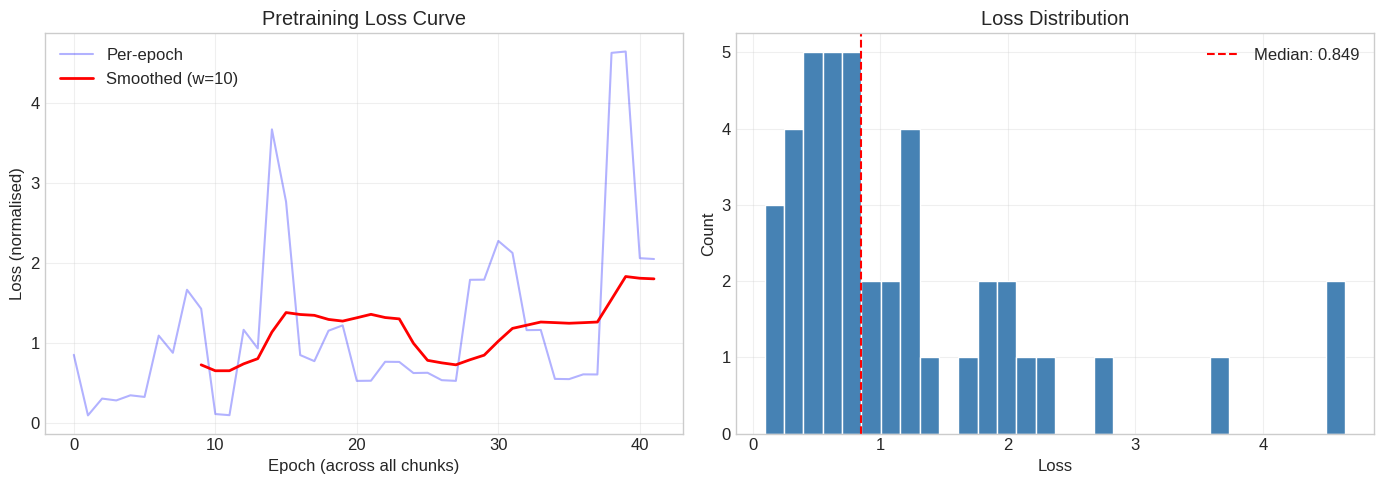


Training Statistics:
  Total epochs: 42
  Loss range: 0.0931 – 4.6450
  Final loss: 2.0494
  Global step: 11484
  Wells processed: 200754


In [50]:
"""
============================================================
Cell 7: Training Diagnostics — run after pretraining
============================================================
"""
import matplotlib.pyplot as plt

if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')
    history = ckpt.get('loss_history', [])

    if history:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Loss curve
        axes[0].plot(history, 'b-', alpha=0.3, label='Per-epoch')
        # Smoothed
        window = min(10, len(history)//3) if len(history) > 6 else 1
        if window > 1:
            smoothed = np.convolve(history, np.ones(window)/window, mode='valid')
            axes[0].plot(range(window-1, len(history)), smoothed, 'r-', linewidth=2, label=f'Smoothed (w={window})')
        axes[0].set_xlabel('Epoch (across all chunks)')
        axes[0].set_ylabel('Loss (normalised)')
        axes[0].set_title('Pretraining Loss Curve')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Loss distribution
        axes[1].hist(history, bins=30, color='steelblue', edgecolor='white')
        axes[1].axvline(np.median(history), color='red', linestyle='--', label=f'Median: {np.median(history):.3f}')
        axes[1].set_xlabel('Loss')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Loss Distribution')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Stats
        print(f"\nTraining Statistics:")
        print(f"  Total epochs: {len(history)}")
        print(f"  Loss range: {min(history):.4f} – {max(history):.4f}")
        print(f"  Final loss: {history[-1]:.4f}")
        print(f"  Global step: {ckpt.get('global_step', '?')}")
        print(f"  Wells processed: {ckpt.get('next_chunk_start', '?')}")
    else:
        print("No loss history found")
else:
    print("No checkpoint found")